# Module 1 — Language Detection

Classifies the language of a user message using TF-IDF features and a Linear SVM.

**Pipeline in this notebook**
1. Setup paths and imports
2. Define four model variants and training helpers
3. Load the [papluca/language-identification](https://huggingface.co/datasets/papluca/language-identification) dataset
4. EDA — language balance and text-length patterns
5. Compare models on train / validation / test
6. Learning curve (test accuracy vs training size)
7. Train the best model and save artifacts to `outputs/module1/` and `models/language_detector.joblib`


## 1. Setup


In [34]:
%matplotlib inline

from __future__ import annotations

import json
from pathlib import Path
from typing import List, Sequence

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.svm import LinearSVC


### Project paths

All module artifacts live under `outputs/module1/` (no nested folders). The trained model is saved to `models/language_detector.joblib`.


In [35]:
_cwd = Path.cwd().resolve()
PROJECT_ROOT = _cwd if (_cwd / "models").is_dir() else _cwd.parent

MODEL_PATH = PROJECT_ROOT / "models" / "language_detector.joblib"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "module1"

# CSV metrics (readable, referenced in README)
TEST_METRICS_CSV = OUTPUT_DIR / "test_metrics.csv"

# Plots
EDA_OVERVIEW_PNG = OUTPUT_DIR / "eda_overview.png"
LEARNING_CURVE_PNG = OUTPUT_DIR / "learning_curve.png"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Outputs:", OUTPUT_DIR)
print("Model:", MODEL_PATH)


Project root: /home/magdy/magdy/NLP/Mental-Health-RAG-Chatbot
Outputs: /home/magdy/magdy/NLP/Mental-Health-RAG-Chatbot/outputs/module1
Model: /home/magdy/magdy/NLP/Mental-Health-RAG-Chatbot/models/language_detector.joblib


## 2. Model definitions

Four scikit-learn pipelines with different TF-IDF feature sets. `build_model_1` is the largest; `build_model_4` is the fastest.


In [36]:
def _make_pipeline(feature_blocks: list, C: float = 1.0) -> Pipeline:
    features = FeatureUnion(feature_blocks, n_jobs=1)
    return Pipeline([("features", features), ("clf", LinearSVC(C=C))])


def build_model_1() -> Pipeline:
    """Char + char_wb + word n-grams (highest capacity)."""
    return _make_pipeline(
        [
            ("char", TfidfVectorizer(analyzer="char", ngram_range=(2, 6), sublinear_tf=True, min_df=2, lowercase=True, max_features=300_000)),
            ("char_wb", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 7), sublinear_tf=True, min_df=2, lowercase=True, max_features=200_000)),
            ("word", TfidfVectorizer(analyzer="word", ngram_range=(1, 2), sublinear_tf=True, min_df=2, lowercase=True, max_features=200_000)),
        ],
        C=3.0,
    )


def build_model_2() -> Pipeline:
    """Char-only — faster training."""
    return _make_pipeline(
        [("char", TfidfVectorizer(analyzer="char", ngram_range=(2, 5), sublinear_tf=True, min_df=2, lowercase=True, max_features=150_000))],
        C=2.0,
    )


def build_model_3() -> Pipeline:
    """char_wb + word n-grams."""
    return _make_pipeline(
        [
            ("char_wb", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 6), sublinear_tf=True, min_df=2, lowercase=True, max_features=200_000)),
            ("word", TfidfVectorizer(analyzer="word", ngram_range=(1, 3), sublinear_tf=True, min_df=2, lowercase=True, max_features=150_000)),
        ],
        C=1.5,
    )


def build_model_4() -> Pipeline:
    """Compact char n-grams — smallest / fastest."""
    return _make_pipeline(
        [("char", TfidfVectorizer(analyzer="char", ngram_range=(3, 5), sublinear_tf=True, min_df=3, lowercase=True, max_features=80_000))],
        C=1.0,
    )


MODEL_BUILDERS = {
    "model_1_full": build_model_1,
    "model_2_char_only": build_model_2,
    "model_3_word_charwb": build_model_3,
    "model_4_compact": build_model_4,
}


## 3. Training and evaluation helpers


In [ ]:
def evaluate_split(model: Pipeline, x: Sequence[str], y: Sequence[str], split_name: str) -> dict:
    preds = model.predict(x)
    return {"split": split_name, "n_samples": len(y), "accuracy": accuracy_score(y, preds)}


def fit_and_score(
    builder,
    name: str,
    x_train_fit: Sequence[str],
    y_train_fit: Sequence[str],
    eval_splits: dict[str, tuple[Sequence[str], Sequence[str]]],
) -> tuple[Pipeline, pd.DataFrame]:
    print(f"\n{'=' * 60}\nTraining: {name}\n{'=' * 60}")
    model = builder()
    model.fit(x_train_fit, y_train_fit)
    rows = [{"model": name, **evaluate_split(model, x, y, split)} for split, (x, y) in eval_splits.items()]
    scores = pd.DataFrame(rows)
    print(scores.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
    return model, scores








In [ ]:
def training_size_curve(
    builder,
    x_train_fit: Sequence[str],
    y_train_fit: Sequence[str],
    x_test_eval: Sequence[str],
    y_test_eval: Sequence[str],
    fractions: tuple[float, ...] = (0.1, 0.2, 0.4, 0.6, 0.8, 1.0),
    random_state: int = 42,
) -> pd.DataFrame:
    rng = np.random.default_rng(random_state)
    indices = rng.permutation(len(x_train_fit))
    rows = []
    for frac in fractions:
        n = max(100, int(len(x_train_fit) * frac))
        idx = indices[:n]
        x_sub = [x_train_fit[i] for i in idx]
        y_sub = [y_train_fit[i] for i in idx]
        model = builder()
        model.fit(x_sub, y_sub)
        train_acc = accuracy_score(y_sub, model.predict(x_sub))
        test_acc = accuracy_score(y_test_eval, model.predict(x_test_eval))
        rows.append({"train_fraction": frac, "train_samples": n, "train_accuracy": train_acc, "test_accuracy": test_acc})
        print(f"  fraction={frac:4.0%} | train_n={n:6d} | train_acc={train_acc:.4f} | test_acc={test_acc:.4f}")
    return pd.DataFrame(rows)

In [38]:
def plot_learning_curve(df: pd.DataFrame, path: Path) -> None:
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(df["train_samples"], df["train_accuracy"], marker="o", label="Train accuracy")
    ax.plot(df["train_samples"], df["test_accuracy"], marker="s", label="Test accuracy")
    ax.set_xlabel("Training samples used")
    ax.set_ylabel("Accuracy")
    ax.set_title("Language detection — accuracy vs training size")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

## 4. Load dataset

Download from Hugging Face and create a stratified validation split (10%) from the training fold.


In [39]:
from datasets import load_dataset

dataset = load_dataset("papluca/language-identification")

x_train_full = list(dataset["train"]["text"])
y_train_full = list(dataset["train"]["labels"])
x_test = list(dataset["test"]["text"])
y_test = list(dataset["test"]["labels"])

x_train, x_val, y_train, y_val = train_test_split(
    x_train_full,
    y_train_full,
    test_size=0.1,
    random_state=42,
    stratify=y_train_full,
)

print("Train (fit):", len(x_train))
print("Validation:", len(x_val))
print("Test:", len(x_test))
print("Languages:", sorted(set(y_train_full)))

pd.DataFrame({"text": x_train[:3], "label": y_train[:3]})


Train (fit): 63000
Validation: 7000
Test: 10000
Languages: ['ar', 'bg', 'de', 'el', 'en', 'es', 'fr', 'hi', 'it', 'ja', 'nl', 'pl', 'pt', 'ru', 'sw', 'th', 'tr', 'ur', 'vi', 'zh']


,text,label
0,Ne guidi uno?,it
1,Een witte en bruine hond loopt over het gras.,nl
2,"Roman fretard , thay vì một danh sách các nhà ...",vi


## 5. Exploratory data analysis (EDA)

Check that classes are balanced and inspect text lengths before training.


In [40]:
LANGUAGE_NAMES = {
    "ar": "Arabic", "bg": "Bulgarian", "de": "German", "el": "Greek", "en": "English",
    "es": "Spanish", "fr": "French", "hi": "Hindi", "it": "Italian", "ja": "Japanese",
    "nl": "Dutch", "pl": "Polish", "pt": "Portuguese", "ru": "Russian", "sw": "Swahili",
    "th": "Thai", "tr": "Turkish", "ur": "Urdu", "vi": "Vietnamese", "zh": "Chinese",
}

SPLIT_LABELS = {
    "train_full": ("Train (full)", y_train_full),
    "train_fit": ("Train (fit)", y_train),
    "val": ("Validation", y_val),
    "test": ("Test", y_test),
}

count_rows = []
for _split_id, (split_name, labels) in SPLIT_LABELS.items():
    for lang, n in pd.Series(labels).value_counts().items():
        count_rows.append({"split": split_name, "lang": lang, "count": int(n)})

counts_long = pd.DataFrame(count_rows)
count_df = counts_long.pivot(index="lang", columns="split", values="count").fillna(0).astype(int)
count_df = count_df.reindex(sorted(count_df.index))

split_summary = pd.DataFrame(
    [
        {
            "split": name,
            "samples": len(labels),
            "languages": len(set(labels)),
            "min_per_lang": pd.Series(labels).value_counts().min(),
            "max_per_lang": pd.Series(labels).value_counts().max(),
        }
        for name, labels in [v for v in SPLIT_LABELS.values()]
    ]
).set_index("split")

display(split_summary)
display(count_df)


,samples,languages,min_per_lang,max_per_lang
split,,,,
Train (full),70000,20,3500,3500
Train (fit),63000,20,3150,3150
Validation,7000,20,350,350
Test,10000,20,500,500


split,Test,Train (fit),Train (full),Validation
lang,,,,
ar,500,3150,3500,350
bg,500,3150,3500,350
de,500,3150,3500,350
el,500,3150,3500,350
en,500,3150,3500,350
es,500,3150,3500,350
fr,500,3150,3500,350
hi,500,3150,3500,350
it,500,3150,3500,350


### EDA plots — distribution and text length


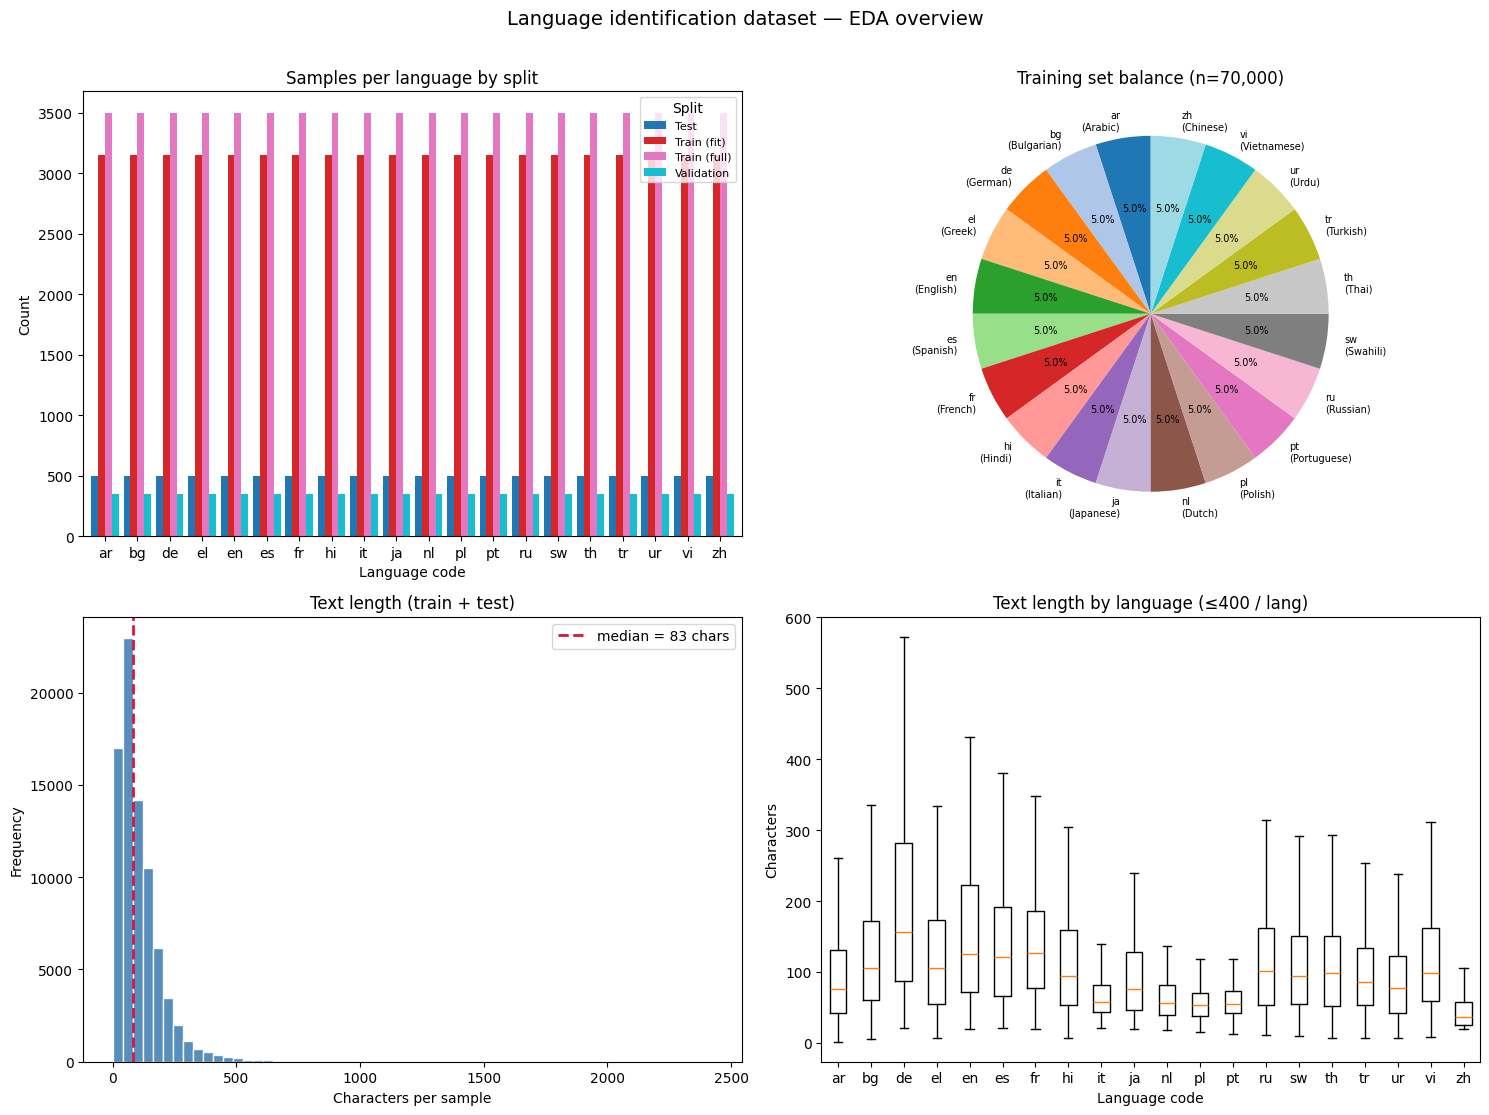

Saved -> /home/magdy/magdy/NLP/Mental-Health-RAG-Chatbot/outputs/module1/eda_overview.png


In [41]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Samples per language (grouped bar)
ax = axes[0, 0]
count_df.plot(kind="bar", ax=ax, width=0.85, colormap="tab10")
ax.set_title("Samples per language by split")
ax.set_xlabel("Language code")
ax.set_ylabel("Count")
ax.legend(title="Split", fontsize=8)
ax.tick_params(axis="x", rotation=0)

# Training-set language share (pie)
ax = axes[0, 1]
train_counts = pd.Series(y_train_full).value_counts().sort_index()
colors = plt.cm.tab20(np.linspace(0, 1, len(train_counts)))
ax.pie(
    train_counts.values,
    labels=[f"{c}\n({LANGUAGE_NAMES.get(c, c)})" for c in train_counts.index],
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    textprops={"fontsize": 7},
)
ax.set_title(f"Training set balance (n={len(y_train_full):,})")

# Text length histogram
ax = axes[1, 0]
all_lengths = np.array([len(t) for t in x_train_full + x_test])
median_len = float(np.median(all_lengths))
ax.hist(all_lengths, bins=60, color="steelblue", edgecolor="white", alpha=0.9)
ax.axvline(median_len, color="crimson", ls="--", lw=2, label=f"median = {median_len:.0f} chars")
ax.set_title("Text length (train + test)")
ax.set_xlabel("Characters per sample")
ax.set_ylabel("Frequency")
ax.legend()

# Length by language (boxplot, sampled)
ax = axes[1, 1]
rng = np.random.default_rng(42)
sample_per_lang = 400
length_by_lang: dict[str, list[int]] = {}
for text, lang in zip(x_train_full, y_train_full):
    length_by_lang.setdefault(lang, []).append(len(text))
box_data, box_labels = [], []
for lang in sorted(length_by_lang):
    arr = np.array(length_by_lang[lang])
    n = min(sample_per_lang, len(arr))
    box_data.append(rng.choice(arr, size=n, replace=False))
    box_labels.append(lang)
ax.boxplot(box_data, tick_labels=box_labels, showfliers=False)
ax.set_title(f"Text length by language (≤{sample_per_lang} / lang)")
ax.set_xlabel("Language code")
ax.set_ylabel("Characters")

fig.suptitle("Language identification dataset — EDA overview", fontsize=14, y=1.01)
fig.tight_layout()
fig.savefig(EDA_OVERVIEW_PNG, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Saved ->", EDA_OVERVIEW_PNG)


### EDA plots — split × language heatmap and proportions


## 6. Compare model variants

Train each pipeline on the fit split and report accuracy on train, validation, and test. The best model is chosen by **validation** accuracy.


In [42]:
EVAL_SPLITS = {
    "train": (x_train, y_train),
    "val": (x_val, y_val),
    "test": (x_test, y_test),
}

all_scores: list[pd.DataFrame] = []
trained_models: dict[str, Pipeline] = {}

for name, builder in MODEL_BUILDERS.items():
    model, scores = fit_and_score(builder, name, x_train, y_train, EVAL_SPLITS)
    trained_models[name] = model
    all_scores.append(scores)

comparison = pd.concat(all_scores, ignore_index=True)
comparison_pivot = comparison.pivot(index="model", columns="split", values="accuracy")[["train", "val", "test"]]

print("\nModel comparison (accuracy)")
display(comparison_pivot.style.format("{:.4f}").highlight_max(axis=0, color="#c8e6c9"))


best_row = comparison.loc[comparison["split"] == "val"].sort_values("accuracy", ascending=False).iloc[0]
BEST_MODEL_NAME = best_row["model"]
print(f"Best on validation: {BEST_MODEL_NAME} (val acc = {best_row['accuracy']:.4f})")


Training: model_1_full
       model split  n_samples  accuracy
model_1_full train      63000    0.9998
model_1_full   val       7000    0.9963
model_1_full  test      10000    0.9958

Training: model_2_char_only
            model split  n_samples  accuracy
model_2_char_only train      63000    0.9998
model_2_char_only   val       7000    0.9970
model_2_char_only  test      10000    0.9954

Training: model_3_word_charwb
              model split  n_samples  accuracy
model_3_word_charwb train      63000    0.9998
model_3_word_charwb   val       7000    0.9951
model_3_word_charwb  test      10000    0.9936

Training: model_4_compact
          model split  n_samples  accuracy
model_4_compact train      63000    0.9995
model_4_compact   val       7000    0.9953
model_4_compact  test      10000    0.9918

Model comparison (accuracy)


split,train,val,test
model,,,
model_1_full,0.9998,0.9963,0.9958
model_2_char_only,0.9998,0.9970,0.9954
model_3_word_charwb,0.9998,0.9951,0.9936
model_4_compact,0.9995,0.9953,0.9918


Best on validation: model_2_char_only (val acc = 0.9970)


## 7. Learning curve

Retrain the best model on increasing fractions of the training data and measure **test** accuracy after each step.


Learning curve: model_2_char_only

  fraction= 10% | train_n=  6300 | train_acc=1.0000 | test_acc=0.9934
  fraction= 20% | train_n= 12600 | train_acc=1.0000 | test_acc=0.9939
  fraction= 40% | train_n= 25200 | train_acc=1.0000 | test_acc=0.9944
  fraction= 60% | train_n= 37800 | train_acc=0.9999 | test_acc=0.9955
  fraction= 80% | train_n= 50400 | train_acc=0.9999 | test_acc=0.9954
  fraction=100% | train_n= 63000 | train_acc=0.9998 | test_acc=0.9954


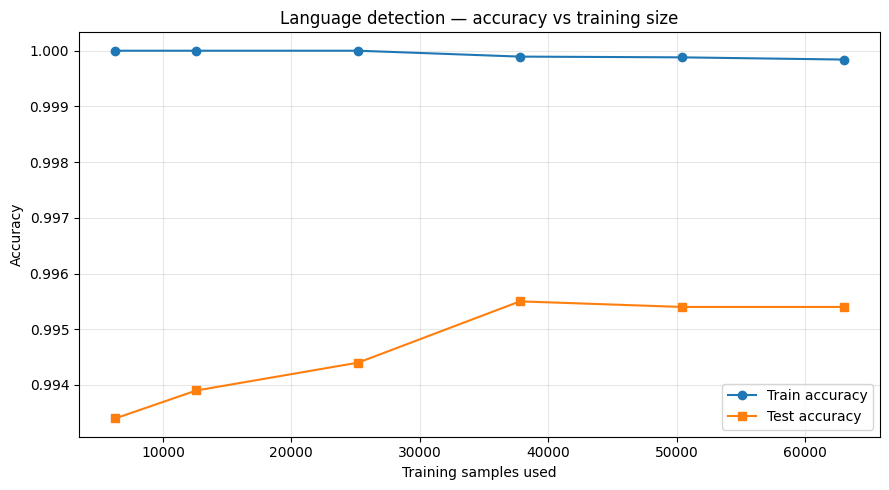

Saved -> /home/magdy/magdy/NLP/Mental-Health-RAG-Chatbot/outputs/module1/learning_curve.png


,train_fraction,train_samples,train_accuracy,test_accuracy
0,0.1,6300,1.000000,0.9934
1,0.2,12600,1.000000,0.9939
2,0.4,25200,1.000000,0.9944
3,0.6,37800,0.999894,0.9955
4,0.8,50400,0.999881,0.9954
5,1.0,63000,0.999841,0.9954


In [43]:
print(f"Learning curve: {BEST_MODEL_NAME}\n")
learning_df = training_size_curve(
    MODEL_BUILDERS[BEST_MODEL_NAME],
    x_train,
    y_train,
    x_test,
    y_test,
)

plot_learning_curve(learning_df, LEARNING_CURVE_PNG)
print("Saved ->", LEARNING_CURVE_PNG)
display(learning_df)


## 8. Final model — train and evaluate

Retrain the best architecture on **train + validation**, evaluate on the held-out test set, and save the model plus metrics used in the README.


In [44]:
x_train_all = x_train + x_val
y_train_all = y_train + y_val

model = MODEL_BUILDERS[BEST_MODEL_NAME]()
print(f"Fitting {BEST_MODEL_NAME} on {len(x_train_all):,} samples...")
model.fit(x_train_all, y_train_all)

preds = model.predict(x_test)
test_accuracy = accuracy_score(y_test, preds)
report = classification_report(y_test, preds, digits=4)

labels = sorted(set(y_test) | set(preds))
cm = confusion_matrix(y_test, preds, labels=labels)

joblib.dump(model, MODEL_PATH)

test_metrics = {
    "best_model": BEST_MODEL_NAME,
    "test_accuracy": round(test_accuracy, 6),
    "n_train": len(x_train_all),
    "n_test": len(y_test),
    "n_languages": len(labels),
}
pd.DataFrame([test_metrics]).to_csv(TEST_METRICS_CSV, index=False)
(OUTPUT_DIR / "test_metrics.json").write_text(json.dumps(test_metrics, indent=2), encoding="utf-8")

print(f"Test accuracy: {test_accuracy:.4f}")
print("Saved ->", MODEL_PATH)
print("Saved ->", TEST_METRICS_CSV)
print()
print(report)


Fitting model_2_char_only on 70,000 samples...
Test accuracy: 0.9953
Saved -> /home/magdy/magdy/NLP/Mental-Health-RAG-Chatbot/models/language_detector.joblib
Saved -> /home/magdy/magdy/NLP/Mental-Health-RAG-Chatbot/outputs/module1/test_metrics.csv

              precision    recall  f1-score   support

          ar     1.0000    0.9980    0.9990       500
          bg     0.9980    1.0000    0.9990       500
          de     1.0000    1.0000    1.0000       500
          el     1.0000    1.0000    1.0000       500
          en     0.9960    1.0000    0.9980       500
          es     0.9980    0.9980    0.9980       500
          fr     0.9980    1.0000    0.9990       500
          hi     1.0000    0.9680    0.9837       500
          it     0.9940    0.9960    0.9950       500
          ja     1.0000    1.0000    1.0000       500
          nl     0.9960    0.9980    0.9970       500
          pl     1.0000    0.9940    0.9970       500
          pt     0.9920    0.9980    0.9950     

## 9. Demo predictions

Quick sanity check on short multilingual examples.


In [45]:
demo_texts = [
    ("en", "I have been feeling anxious and overwhelmed for the past few weeks."),
    ("ar", "كيف حالك اليوم؟ أشعر بالقلق منذ عدة أيام."),
    ("fr", "Bonjour, comment allez-vous aujourd'hui ?"),
    ("de", "Wie geht es Ihnen heute? Ich schlafe schlecht."),
    ("ja", "こんにちは、お元気ですか？最近よく眠れません。"),
]

print(f"Demo — {BEST_MODEL_NAME}\n")
for expected, text in demo_texts:
    pred = model.predict([text])[0]
    ok = "OK" if pred == expected else "??"
    snippet = text if len(text) <= 48 else text[:45] + "..."
    print(f"  [{ok}] expected={expected} predicted={pred} | {snippet}")


Demo — model_2_char_only

  [OK] expected=en predicted=en | I have been feeling anxious and overwhelmed f...
  [OK] expected=ar predicted=ar | كيف حالك اليوم؟ أشعر بالقلق منذ عدة أيام.
  [OK] expected=fr predicted=fr | Bonjour, comment allez-vous aujourd'hui ?
  [OK] expected=de predicted=de | Wie geht es Ihnen heute? Ich schlafe schlecht.
  [OK] expected=ja predicted=ja | こんにちは、お元気ですか？最近よく眠れません。
